<a href="https://colab.research.google.com/github/Rajesh2015/Neural-Networks-Projects/blob/main/CNN%20Projects/Face_Recognization_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Computer Vision Face Recogonition


### Part A :Build Face Detection System

In [20]:
# Import required lib
import os
import sys
import random

import numpy as np
import pandas as pd
import tensorflow as tf


import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import math
from sklearn.model_selection import train_test_split
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda,SpatialDropout2D,ZeroPadding2D, Dropout, Flatten, Activation,Convolution2D
from tensorflow.python.keras import losses
from keras.models import Model, load_model
import keras.optimizers as optimizers
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential



### UTILS

In [ ]:
def show_image_and_mask_side_by_side(img_arr,mask_arr,model=None):
    """
    Visualizes a sample image, its true mask (label), and optionally the predicted mask.

    Parameters:
    -----------
    img_arr : numpy.ndarray
    mask_arr : numpy.ndarray


    model :  optional (default=None)
    Displays:
    ---------
    A matplotlib figure with:
      - Original input image
      - Ground truth mask
      - Predicted mask (if show_prediction=True)
    """

    if model:
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 6))
    else:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

    ax1.imshow(img_arr)
    ax1.set_title("Original Image")
    ax1.axis("off")

    ax2.imshow(mask_arr)
    ax2.set_title("Original Mask")
    ax2.axis("off")

    if model:
        prediction = model.predict(img_arr.reshape(1, 224, 224, 3))[0]
        ax3.imshow(prediction)
        ax3.set_title("Predicted Mask")
        ax3.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
def augment_np(image, mask):
    """
    Augments a numpy image and mask.
    Parameters:
    -----------
    image : numpy.ndarray
    mask : numpy.ndarray
    Returns:
    --------
    image : numpy.ndarray
    mask : numpy.ndarray
    """
    # Convert to tensors
    image = tf.convert_to_tensor(image)
    mask = tf.convert_to_tensor(mask)

    # Make sure mask has shape (H, W, 1)
    if mask.ndim == 2:
        mask = tf.expand_dims(mask, axis=-1)

    # Apply same augmentations to both
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

    # Return as NumPy arrays
    return image.numpy(), tf.squeeze(mask).numpy()

In [ ]:
def set_seeds(seed=42):
  """
  Sets the seeds for reproducibility.
  Parameters:
  -----------
  seed : int, default=42
  """
  os.environ['PYTHONHASHSEED'] = str(seed)
  random.seed(seed)
  np.random.seed(seed)
  tf.random.set_seed(seed)

In [ ]:
def show_prediction_overlay(image, mask, idx=0, alpha=0.4, resize_to=(128, 128)):
    """
    Displays original image and predicted mask overlay side by side.

    Parameters:
    - image: array of test images (e.g., X_test)
    - mask: array of predicted masks (e.g., pred_test)
    - idx: index of the image to display
    - alpha: transparency of the mask overlay
    - resize_to: size to downscale the images (width, height)
    """
    img = image[idx]
    pred = (mask[idx] > 0.5).astype(np.uint8).squeeze()

    # Resize image and prediction
    img_resized = cv2.resize(img, resize_to)
    if pred.ndim == 2:
        pred_resized = cv2.resize(pred, resize_to, interpolation=cv2.INTER_NEAREST)
    else:
        pred_resized = cv2.resize(pred[..., 0], resize_to, interpolation=cv2.INTER_NEAREST)

    # Create overlay
    overlay = img_resized.copy()
    color = [255, 0, 0]  # Red overlay
    for c in range(3):
        overlay[..., c] = np.where(pred_resized == 1,
                                   overlay[..., c] * (1 - alpha) + alpha * color[c],
                                   overlay[..., c])

    # Plot
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_resized.astype(np.uint8))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay.astype(np.uint8))
    plt.title("Prediction Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### Read data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = np.load('/content/drive/MyDrive/Python Course_shared/computer Vision/Images.npy', allow_pickle=True)

In [ ]:
data.shape

(393, 2)

In [ ]:
data

array([[array([[[42, 37, 34],
                [56, 51, 48],
                [71, 66, 63],
                ...,
                [23, 33, 34],
                [26, 36, 37],
                [28, 38, 39]],

               [[40, 35, 32],
                [51, 46, 43],
                [64, 59, 56],
                ...,
                [27, 36, 35],
                [24, 33, 32],
                [26, 35, 34]],

               [[43, 38, 35],
                [51, 46, 43],
                [61, 56, 53],
                ...,
                [28, 30, 27],
                [33, 35, 32],
                [35, 37, 34]],

               ...,

               [[56, 47, 40],
                [57, 48, 41],
                [61, 52, 45],
                ...,
                [67, 48, 42],
                [55, 35, 28],
                [60, 40, 33]],

               [[53, 44, 37],
                [54, 45, 38],
                [57, 48, 41],
                ...,
                [59, 40, 34],
                [60, 40, 3

In [ ]:
data[0][1]

[{'label': ['Face'],
  'notes': '',
  'points': [{'x': 0.08615384615384615, 'y': 0.3063063063063063},
   {'x': 0.1723076923076923, 'y': 0.45345345345345345}],
  'imageWidth': 650,
  'imageHeight': 333},
 {'label': ['Face'],
  'notes': '',
  'points': [{'x': 0.583076923076923, 'y': 0.2912912912912913},
   {'x': 0.6584615384615384, 'y': 0.46846846846846846}],
  'imageWidth': 650,
  'imageHeight': 333}]

##### Show Some Image

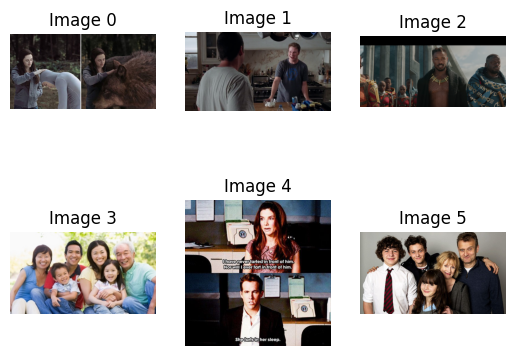

In [ ]:
# Show first 5 images
for index in range(0,6,1):
    plt.subplot(2, 3, index + 1)  # Create a 2-row, 3-column grid  plt.imshow(data[index][0])
    plt.imshow(data[index][0])  # Show the image
    plt.axis("off")  # Hide axes
    plt.title(f"Image {index}")  # Add a title

##### Find out Image which have more then 3 channels

In [ ]:
for index in range(data.shape[0]):
    img = data[index][0]  # Extract the image

    if len(img.shape) == 2:
        print(f"Image {index} is grayscale (shape: {img.shape})")
    elif img.shape[2] == 4:
        print(f"Image {index} has an alpha channel (RGBA) (shape: {img.shape})")
    elif img.shape[2] != 3:
        print(f"Image {index} has an unexpected number of channels: {img.shape}")

Image 1 has an alpha channel (RGBA) (shape: (697, 1280, 4))
Image 2 has an alpha channel (RGBA) (shape: (291, 600, 4))
Image 39 has an alpha channel (RGBA) (shape: (340, 516, 4))
Image 47 has an alpha channel (RGBA) (shape: (600, 800, 4))
Image 62 has an alpha channel (RGBA) (shape: (312, 750, 4))
Image 134 has an alpha channel (RGBA) (shape: (330, 538, 4))
Image 145 has an alpha channel (RGBA) (shape: (496, 860, 4))
Image 237 has an alpha channel (RGBA) (shape: (379, 505, 4))
Image 251 has an alpha channel (RGBA) (shape: (400, 770, 4))
Image 260 is grayscale (shape: (350, 650))
Image 325 has an alpha channel (RGBA) (shape: (267, 740, 4))
Image 335 has an alpha channel (RGBA) (shape: (281, 600, 4))


In [ ]:
IMAGE_HEIGHT=224
IMAGE_WIDTH=224

In [ ]:
masks = np.zeros((data.shape[0], IMAGE_HEIGHT, IMAGE_WIDTH), dtype=np.uint8)
image = np.zeros((data.shape[0], IMAGE_HEIGHT, IMAGE_WIDTH, 3), dtype=np.uint8)

for index in range(data.shape[0]):
    img = data[index][0]

    # Resize first
    img = cv2.resize(img, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_CUBIC)

    # Normalize channels: make sure image has exactly 3 channels
    if img.ndim == 2:  # grayscale
        img = np.stack([img] * 3, axis=-1)
    elif img.shape[2] < 3:
        # Pad missing channels with zeros
        pad = np.zeros((img.shape[0], img.shape[1], 3 - img.shape[2]), dtype=img.dtype)
        img = np.concatenate((img, pad), axis=-1)
    elif img.shape[2] > 3:
        img = img[:, :, :3]  # Take only first 3 channels

    image[index] = img

    # Create the mask from annotation
    for box in data[index][1]:
        x1 = int(box["points"][0]['x'] * IMAGE_WIDTH)
        y1 = int(box["points"][0]['y'] * IMAGE_HEIGHT)
        x2 = int(box["points"][1]['x'] * IMAGE_WIDTH)
        y2 = int(box["points"][1]['y'] * IMAGE_HEIGHT)

        # Clamp to valid range
        x1, x2 = max(0, x1), min(IMAGE_WIDTH, x2)
        y1, y2 = max(0, y1), min(IMAGE_HEIGHT, y2)

        masks[index][y1:y2, x1:x2] = 1


In [ ]:
size=math.ceil(image.shape[0] * 80 / 100)
print(f"Training {size} and Test Size {image.shape[0]-size}")
X_train=image[:size]
y_train=masks[:size]
X_test=image[size:]
y_test=masks[size:]

Training 315 and Test Size 78


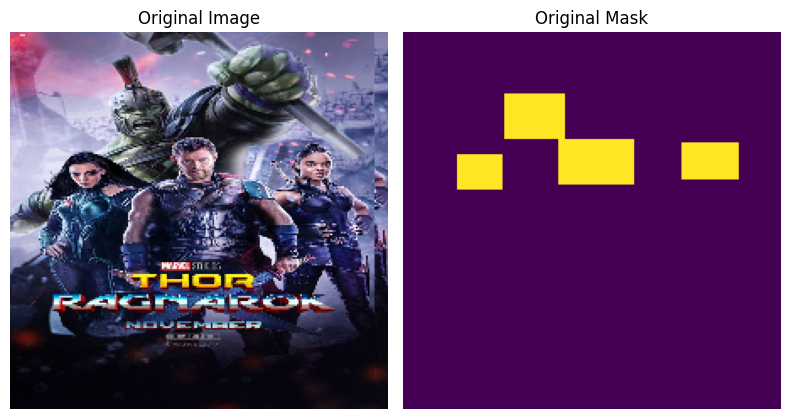

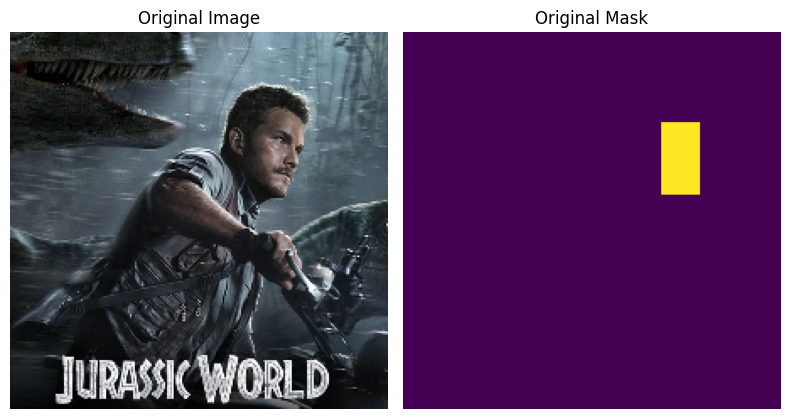

In [ ]:
import random
index=random.randint(0,X_train.shape[0])
show_image_and_mask_side_by_side(X_train[index],y_train[index])
index=random.randint(0,X_train.shape[0])
show_image_and_mask_side_by_side(X_train[index],y_train[index])


### Model Building
- Addding ResNet as model with below parameter values
        input_shape: IMAGE_HEIGHT, IMAGE_WIDTH, 3
        include_top: False
        weights: "imagenet"
- UNET architecture layers


#### Custom Loss function

In [ ]:
from tensorflow.keras import backend as K

def dice_coeff(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

Resnet50 Model Creation

In [ ]:
def unet_resnet50(input_shape=(224, 224, 3), freeze_encoder=True):
    inputs = Input(shape=input_shape)

    # Load ResNet50 with pretrained weights, exclude top layers
    base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)

    # Freeze encoder if desired
    if freeze_encoder:
        for layer in base_model.layers:
            layer.trainable = False

    # Extract skip connections
    skips = [
        base_model.get_layer("conv1_relu").output,    # 112x112
        base_model.get_layer("conv2_block3_out").output, # 56x56
        base_model.get_layer("conv3_block4_out").output, # 28x28
        base_model.get_layer("conv4_block6_out").output  # 14x14
    ]
    encoder_output = base_model.get_layer("conv5_block3_out").output  # 7x7

    # Decoder
    x = encoder_output
    for skip in reversed(skips):
        x = Conv2DTranspose(skip.shape[-1], (3, 3), strides=2, padding='same')(x)
        x = Concatenate()([x, skip])
        x = Conv2D(skip.shape[-1], (3, 3), activation='relu', padding='same')(x)
        x = Dropout(0.3)(x)
        x = Conv2D(skip.shape[-1], (3, 3), activation='relu', padding='same')(x)

    # Final upsampling to match original input size
    x = Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)
    x = Conv2D(1, (1, 1), activation='sigmoid')(x)  # For binary segmentation

    return Model(inputs, x)

In [ ]:
# Convert to float32 before preprocessing  resnet preprocessing
X_resNet_train = tf.keras.applications.resnet.preprocess_input(X_train.astype('float32'))
X_resNet_test = tf.keras.applications.resnet.preprocess_input(X_test.astype('float32'))

In [ ]:
set_seeds(43)
unet_resnet50_model = unet_resnet50(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))
unet_resnet50_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 85,819,841 (327.38 MB)

 Trainable params: 62,232,129 (237.40 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
unet_resnet50_model.compile(loss=bce_dice_loss, optimizer='adam',  metrics=[dice_loss, dice_coeff])

In [ ]:
print("X shape:", X_resNet_train.shape)
print("masks shape:", y_train.shape)

X shape: (315, 224, 224, 3)
masks shape: (315, 224, 224)


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Any NaNs in X_train?", np.isnan(X_train).any())
print("Any NaNs in y_train?", np.isnan(y_train).any())
print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)

X_train shape: (315, 224, 224, 3)
y_train shape: (315, 224, 224)
Any NaNs in X_train? False
Any NaNs in y_train? False
X_train dtype: uint8
y_train dtype: uint8


In [ ]:
checkpoint = ModelCheckpoint("model-{loss:.2f}.weights.h5", monitor="loss", verbose=1, save_best_only=True,
                             save_weights_only=True, mode="min")
stop = EarlyStopping(monitor="loss", patience=5, mode="min")
reduce_lr = ReduceLROnPlateau(monitor="loss", factor=0.2, patience=5, min_lr=1e-6, verbose=1, mode="min")


In [ ]:
unet_resnet50_model.fit(X_train, y_train, epochs=10, batch_size=8, callbacks=[checkpoint, reduce_lr, stop])

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - dice_coeff: 0.1452 - dice_loss: 0.8548 - loss: 1.3729
Epoch 1: loss improved from inf to 1.23940, saving model to model-1.24.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - dice_coeff: 0.1465 - dice_loss: 0.8535 - loss: 1.3697 - learning_rate: 0.0010
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - dice_coeff: 0.3775 - dice_loss: 0.6225 - loss: 0.9685
Epoch 2: loss improved from 1.23940 to 0.86881, saving model to model-0.87.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - dice_coeff: 0.3792 - dice_loss: 0.6208 - loss: 0.9660 - learning_rate: 0.0010
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - dice_coeff: 0.5233 - dice_loss: 0.4767 - loss: 0.7645
Epoch 3: loss improved from 0.86881 to 0.70049, saving model to model-0.70.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - dice_coeff: 0.5242 - dice_loss: 0.4758 - loss: 0.7629 - learning_rate: 0.0010
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - dice_coeff:

In [ ]:
# Evaluate the model.
result_score = unet_resnet50_model.evaluate(X_resNet_test, y_test, batch_size=4, verbose=1)
print(f"Test Loss: {result_score[0]:.4f}")
print(f"Dice Loss: {result_score[1]:.4f}")
print(f"Dice Coefficient: {result_score[2]:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - dice_coeff: 0.6059 - dice_loss: 0.3941 - loss: 0.6671
Test Loss: 0.7270
Dice Loss: 0.4338
Dice Coefficient: 0.5662


### Observation:
Model performance for test is around .60 which is not that great we will try optimising it

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


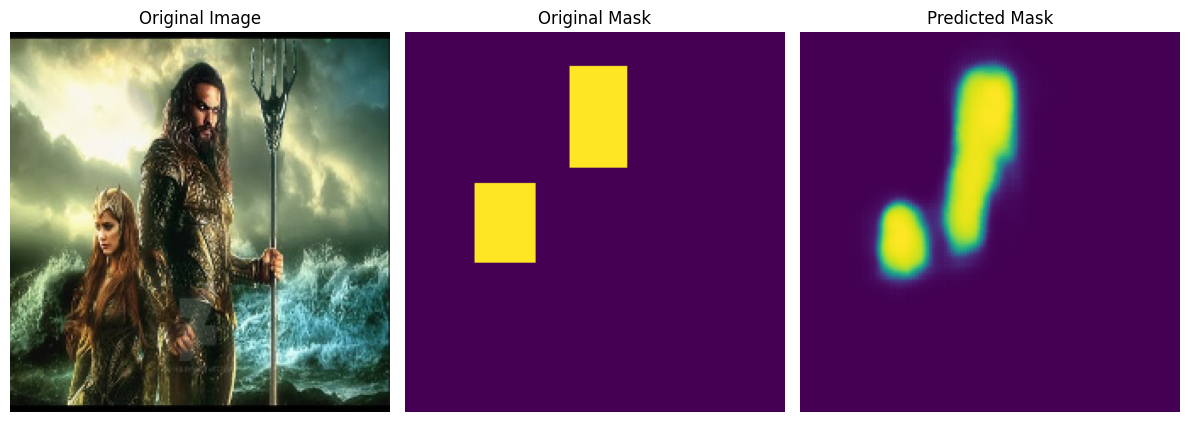

In [ ]:
show_image_and_mask_side_by_side(X_test[1],y_test[1],unet_resnet50_model)

####  Data Augomentation


Image Augomentation and Model Creation

In [ ]:
X_train_aug = []
y_train_aug = []

for img, mask in zip(X_train, y_train):

    augmented_img, augmented_mask = augment_np(img, mask)
    X_train_aug.append(augmented_img)
    y_train_aug.append(augmented_mask)

X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

X_train_full = np.concatenate([X_train, X_train_aug], axis=0)
y_train_full = np.concatenate([y_train, y_train_aug], axis=0)

In [ ]:
X_train_full.shape

(630, 224, 224, 3)

In [ ]:
# Convert to float32 before preprocessing  resnet preprocessing
X_resNet_train_full = tf.keras.applications.resnet.preprocess_input(X_train_full.astype('float32'))


In [ ]:
backend.clear_session()
set_seeds(43)
checkpoint2 = ModelCheckpoint("model-{loss:.2f}.weights.h5", monitor="loss", verbose=1, save_best_only=True,
                             save_weights_only=True, mode="min")
stop2 = EarlyStopping(monitor="loss", patience=5, mode="min")
reduce_lr2 = ReduceLROnPlateau(monitor="loss", factor=0.2, patience=5, min_lr=1e-6, verbose=1, mode="min")
unet_resnet50_model_2 = unet_resnet50(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))
unet_resnet50_model_2.compile(loss=bce_dice_loss, optimizer='adam',  metrics=[dice_loss, dice_coeff])
unet_resnet50_model_2.fit(X_resNet_train_full, y_train_full, epochs=10, batch_size=20, callbacks=[checkpoint2, reduce_lr2, stop2])

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - dice_coeff: 0.1849 - dice_loss: 0.8151 - loss: 1.3494
Epoch 1: loss improved from inf to 1.20812, saving model to model-1.21.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - dice_coeff: 0.1862 - dice_loss: 0.8138 - loss: 1.3451 - learning_rate: 0.0010
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - dice_coeff: 0.4237 - dice_loss: 0.5763 - loss: 0.8962
Epoch 2: loss improved from 1.20812 to 0.90575, saving model to model-0.91.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - dice_coeff: 0.4238 - dice_loss: 0.5762 - loss: 0.8965 - learning_rate: 0.0010
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - dice_coeff: 0.4183 - dice_loss: 0.5817 - loss: 0.8895
Epoch 3: loss improved from 0.90575 to 0.82512, saving model to model-0.83.weights.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - dice_coeff: 0.4201 - dice_loss: 0.5799 - loss: 0.8875 - learning_rate: 0.0010
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - dice_coef

In [ ]:
# Evaluate the model.
result_score = unet_resnet50_model_2.evaluate(X_resNet_test, y_test, batch_size=4, verbose=1)
print(f"Test Loss: {result_score[0]:.4f}")
print(f"Dice Loss: {result_score[1]:.4f}")
print(f"Dice Coefficient: {result_score[2]:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - dice_coeff: 0.6419 - dice_loss: 0.3581 - loss: 0.5549
Test Loss: 0.5938
Dice Loss: 0.3895
Dice Coefficient: 0.6105


#### Base Model :MobilenetV2

In [ ]:
def unet_mobilenetv2(input_shape=(224, 224, 3), freeze_encoder=True):
    inputs = Input(shape=input_shape)

    # Load MobileNetV2 as encoder
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)

    if freeze_encoder:
        for layer in base_model.layers:
            layer.trainable = False

    # Skip connections
    skips = [
        base_model.get_layer('block_1_expand_relu').output,   # 112x112
        base_model.get_layer('block_3_expand_relu').output,   # 56x56
        base_model.get_layer('block_6_expand_relu').output,   # 28x28
        base_model.get_layer('block_13_expand_relu').output   # 14x14
    ]
    encoder_output = base_model.get_layer('block_16_project').output  # 7x7

    # Decoder
    x = encoder_output
    for skip in reversed(skips):
        x = Conv2DTranspose(skip.shape[-1], (3, 3), strides=2, padding='same')(x)
        x = Concatenate()([x, skip])
        x = Conv2D(skip.shape[-1], (3, 3), activation='relu', padding='same')(x)
        x = Dropout(0.3)(x)
        x = Conv2D(skip.shape[-1], (3, 3), activation='relu', padding='same')(x)

    # Final upsampling and output
    x = Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(x)

    return Model(inputs, outputs)


In [ ]:
X_mobilenet_train = tf.keras.applications.mobilenet_v2.preprocess_input(X_train.astype('float32'))
X_mobilenet_test = tf.keras.applications.mobilenet_v2.preprocess_input(X_test.astype('float32'))

In [ ]:
backend.clear_session()
set_seeds(43)
checkpoint2 = ModelCheckpoint("model-{loss:.2f}.weights.h5", monitor="loss", verbose=1, save_best_only=True,
                             save_weights_only=True, mode="min")
stop2 = EarlyStopping(monitor="loss", patience=5, mode="min")
reduce_lr2 = ReduceLROnPlateau(monitor="loss", factor=0.2, patience=5, min_lr=1e-6, verbose=1, mode="min")
unet_mobilev2_model = unet_mobilenetv2(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))
unet_mobilev2_model.compile(loss=bce_dice_loss, optimizer='adam',  metrics=[dice_loss, dice_coeff])
unet_mobilev2_model.fit(X_mobilenet_train, y_train, epochs=25, batch_size=8, callbacks=[checkpoint2, reduce_lr2, stop2])

<ipython-input-91-bb599059fa72>:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)


Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - dice_coeff: 0.1431 - dice_loss: 0.8569 - loss: 1.3408
Epoch 1: loss improved from inf to 1.26376, saving model to model-1.26.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 51s 827ms/step - dice_coeff: 0.1435 - dice_loss: 0.8565 - loss: 1.3389 - learning_rate: 0.0010
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - dice_coeff: 0.2522 - dice_loss: 0.7478 - loss: 1.1173
Epoch 2: loss improved from 1.26376 to 0.99103, saving model to model-0.99.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 577ms/step - dice_coeff: 0.2549 - dice_loss: 0.7451 - loss: 1.1142 - learning_rate: 0.0010
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - dice_coeff: 0.4462 - dice_loss: 0.5538 - loss: 0.8592
Epoch 3: loss improved from 0.99103 to 0.76807, saving model to model-0.77.weights.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 39s 516ms/step - dice_coeff: 0.4478 - dice_loss: 0.5522 - loss: 0.8570 - learning_rate: 0.0010
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - di

In [ ]:
result_score = unet_mobilev2_model.evaluate(X_mobilenet_test, y_test, batch_size=8, verbose=1)
print(f"Test Loss: {result_score[0]:.4f}")
print(f"Dice Loss: {result_score[1]:.4f}")
print(f"Dice Coefficient: {result_score[2]:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 321ms/step - dice_coeff: 0.6769 - dice_loss: 0.3231 - loss: 0.5290
Test Loss: 0.5348
Dice Loss: 0.3253
Dice Coefficient: 0.6747


In [ ]:
pred_test= unet_mobilev2_model.predict(X_mobilenet_test, verbose=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step


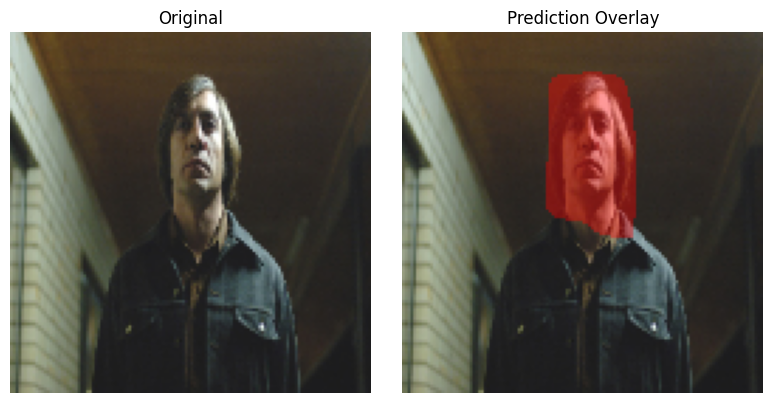

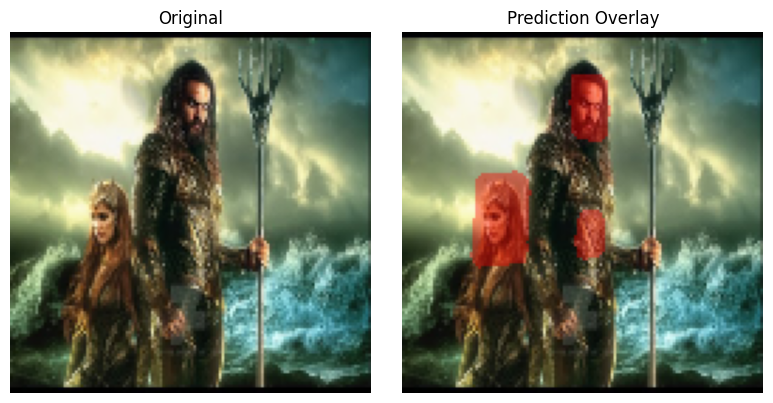

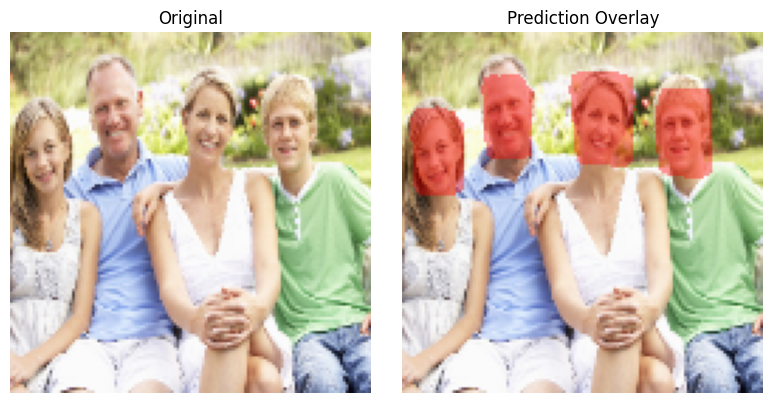

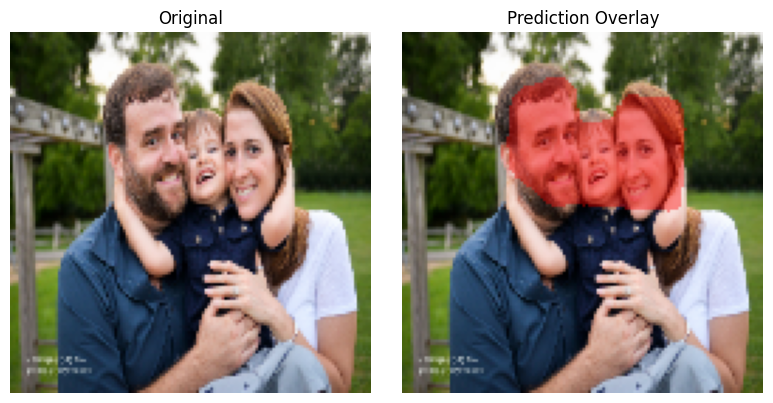

In [ ]:
for index in range(4):
    show_prediction_overlay(X_test, pred_test, idx=index)

## PART B : To create image dataset which need to be used by AI team to build image classifier data

In [ ]:
!unzip '/content/drive/MyDrive/Python Course_shared/computer Vision/training_images-20211126T092819Z-001.zip'

Archive:  /content/drive/MyDrive/Python Course_shared/computer Vision/training_images-20211126T092819Z-001.zip
  inflating: training_images/real_00947.jpg  
  inflating: training_images/real_01052.jpg  
  inflating: training_images/real_01042.jpg  
  inflating: training_images/real_00964.jpg  
  inflating: training_images/real_01053.jpg  
  inflating: training_images/real_00971.jpg  
  inflating: training_images/real_01057.jpg  
  inflating: training_images/real_01044.jpg  
  inflating: training_images/real_01041.jpg  
  inflating: training_images/real_01067.jpg  
  inflating: training_images/real_00969.jpg  
  inflating: training_images/real_00956.jpg  
  inflating: training_images/real_00975.jpg  
  inflating: training_images/real_01021.jpg  
  inflating: training_images/real_00945.jpg  
  inflating: training_images/real_01068.jpg  
  inflating: training_images/real_01062.jpg  
  inflating: training_images/real_01016.jpg  
  inflating: training_images/real_01065.jpg  
  inflating: tr

In [ ]:
image_folder = '/content/training_images/'
image_files = os.listdir(image_folder)

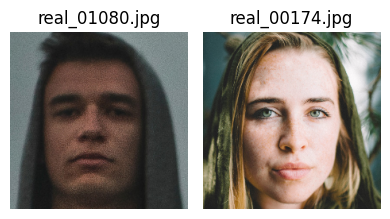

In [ ]:
# Show some images from the unzipped folder
fig, axes = plt.subplots(1, 2, figsize=(4, 5))  # 1 row, 2 columns

for i, file in enumerate(image_files[:2]):
    path = os.path.join(image_folder, file)
    img = cv2.imread(path)

    if img is None:
        continue

    img_resized = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(file)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


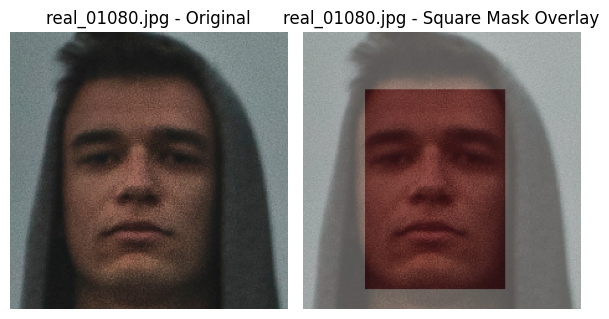

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


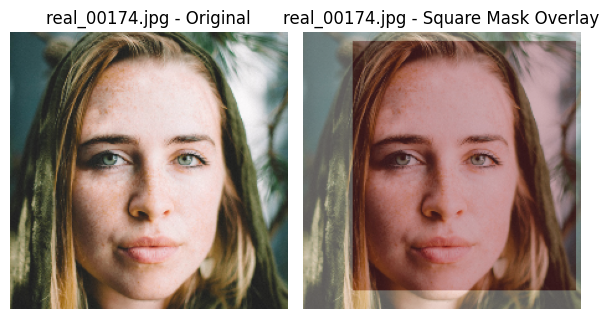

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


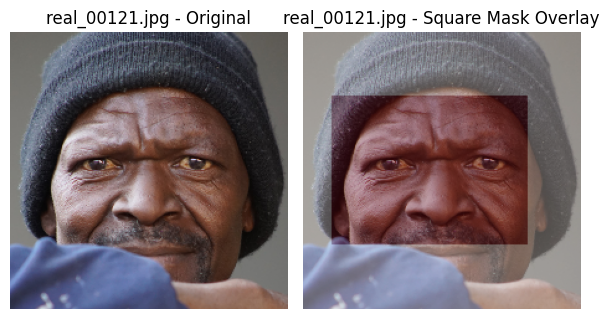

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


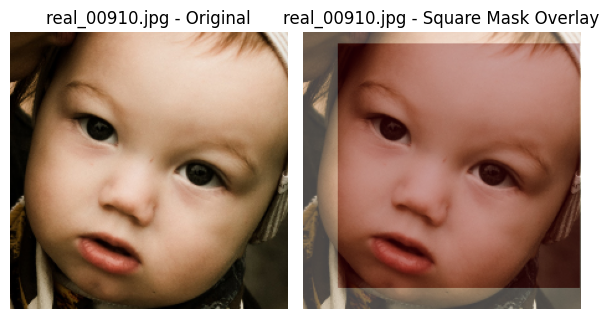

In [ ]:
for i, file in enumerate(image_files[:4]):
    path = os.path.join(image_folder, file)
    img = cv2.imread(path)

    if img is None:
        continue

    original_size = img.shape[:2]  # (height, width)
    img_resized = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    # Normalize and predict
    img_input = img_resized / 255.0
    img_input = np.expand_dims(img_input, axis=0)
    pred_mask = unet_mobilev2_model.predict(img_input)[0]
    pred_mask = (pred_mask > 0.5).astype(np.uint8)
    pred_mask_resized = cv2.resize(pred_mask, (224, 224))

    # Get bounding box
    contours, _ = cv2.findContours(pred_mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    square_mask = np.zeros_like(pred_mask_resized)
    if contours:
        x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
        cv2.rectangle(square_mask, (x, y), (x + w, y + h), 1, -1)  # filled rectangle

    # Plot original and square mask overlay
    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    axes[0].imshow(img_rgb)
    axes[0].set_title(f"{file} - Original")
    axes[0].axis('off')

    axes[1].imshow(img_rgb)
    axes[1].imshow(square_mask, cmap='Reds', alpha=0.3)
    axes[1].set_title(f"{file} - Square Mask Overlay")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
results = []

for file in image_files:
    path = os.path.join(image_folder, file)
    img = cv2.imread(path)

    if img is None:
        continue

    original_size = img.shape[:2]
    img_resized = cv2.resize(img, (224, 224))
    img_array = img_resized / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred_mask = unet_mobilev2_model.predict(img_array)[0]
    pred_mask = (pred_mask > 0.5).astype(np.uint8)
    pred_mask = cv2.resize(pred_mask, (original_size[1], original_size[0]))

    contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        # Save to DataFrame
        results.append({
            'Image': file,
            'Face_X': x,
            'Face_Y': y,
            'Face_Width': w,
            'Face_Height': h
        })

    else:
        results.append({
            'Image': file,
            'Face_X': None,
            'Face_Y': None,
            'Face_Width': w,
            'Face_Height': h
        })


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━

In [ ]:
results_df = pd.DataFrame(results)
results_df.head(5)
results_df.to_csv('training_images_metadata.csv', index=False,header=True)

##PART C :To Build Face Recogonization System

### READ DATA From PINS.zip

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



### Q1 - Extract and load 'PINS'


In [4]:
!unzip '/content/drive/MyDrive/Python Course_shared/computer Vision/PINS.zip'

Streaming output truncated to the last 5000 lines.
  inflating: PINS/pins_kiernan shipka/kiernan shipka 1.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 10.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 100.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 101.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 102.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 103.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 104.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 105.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 106.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 107.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 108.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 109.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 11.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 110.jpg  
  inflating: PINS/pins_kiernan shipka/kiernan shipka 111.jpg  
  inflat

In [7]:
pins_image_folder = '/content/PINS/'

In [8]:
class IdentityMetadata():
    def __init__(self, base, name, file):
        # print(base, name, file)
        # dataset base directory
        self.base = base
        # identity name
        self.name = name
        # image file name
        self.file = file

    def __repr__(self):
        return self.image_path()

    def image_path(self):
        return os.path.join(self.base, self.name, self.file)




### Q3 - Function to load metadata

In [9]:
def load_metadata(path):
    metadata = []
    for i in os.listdir(path):
        for f in os.listdir(os.path.join(path, i)):
            # Check file extension. Allow only jpg/jpeg' files.
            ext = os.path.splitext(f)[1]
            if ext == '.jpg' or ext == '.jpeg':
                metadata.append(IdentityMetadata(path, i, f))
    return np.array(metadata)

In [10]:
# Read & Load Image
def load_image(path):
  """
  Load image from path
  """
  img = cv2.imread(path)
  # Convert to RGB
  return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


In [11]:
metadata = load_metadata(pins_image_folder)

In [12]:
metadata.shape

(10770,)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
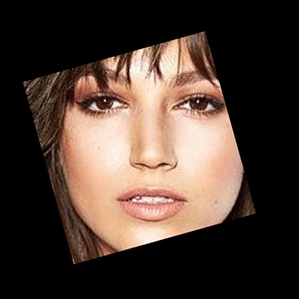

In [13]:
load_image(metadata[0].image_path())

In [14]:
def vgg_face():
    model = Sequential()
    model.add(ZeroPadding2D((1,1),input_shape=(224,224, 3)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(Convolution2D(4096, (7, 7), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(4096, (1, 1), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(2622, (1, 1)))
    model.add(Flatten())
    model.add(Activation('softmax'))
    return model

#### Model Building
- Load the vgg face model
- Load the given weight file named "vgg_face_weights.h5"


In [21]:
model = vgg_face()
model.load_weights('vgg_face_weights.h5')

In [22]:
vgg_face_descriptor = Model(inputs=model.layers[0].input, outputs=model.layers[-2].output)

##### Generate embeddings Vector for each image in the dataset

In [24]:
# Get embedding vector for first image in the metadata using the pre-trained model

img_path = metadata[0].image_path()
img = load_image(img_path)

# Normalising pixel values from [0-255] to [0-1]: scale RGB values to interval [0,1]
img = (img / 255.).astype(np.float32)

img = cv2.resize(img, dsize = (224,224))
print(img.shape)

# Obtain embedding vector for an image
# Get the embedding vector for the above image using vgg_face_descriptor model and print the shape

embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
print(embedding_vector.shape)

(224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
(2622,)


Create Embeddings For each image by calling predict on all metadata and store in embeddings

In [ ]:
embeddings = np.zeros((metadata.shape[0], 2622))

for i, m in enumerate(metadata):
  img = load_image(m.image_path())
  img = (img / 255.).astype(np.float32)
  image = cv2.resize(img, dsize = (224,224))
  embedd_vector = vgg_face_descriptor.predict(np.expand_dims(image, axis=0))[0]
  print(embedd_vector.shape)